In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from tqdm import tqdm

## Item categories

In [2]:
item_categories_df = pd.read_csv("../data/item_categories.csv")

In [3]:
item_categories_df.head()

,item_category_name,item_category_id
0,PC - Гарнитуры/Наушники,0
1,Аксессуары - PS2,1
2,Аксессуары - PS3,2
3,Аксессуары - PS4,3
4,Аксессуары - PSP,4


In [4]:
# total count, not-null count, structure
item_categories_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   item_category_name  84 non-null     str  
 1   item_category_id    84 non-null     int64
dtypes: int64(1), str(1)
memory usage: 1.4 KB


## Items

In [5]:
items_df = pd.read_csv('../data/items.csv')

In [6]:
items_df.head()

,item_name,item_id,item_category_id
0,! ВО ВЛАСТИ НАВАЖДЕНИЯ (ПЛАСТ.) D,0,40
1,!ABBYY FineReader 12 Professional Edition Full...,1,76
2,***В ЛУЧАХ СЛАВЫ (UNV) D,2,40
3,***ГОЛУБАЯ ВОЛНА (Univ) D,3,40
4,***КОРОБКА (СТЕКЛО) D,4,40


In [7]:
# total count, not-null count, structure
items_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 22170 entries, 0 to 22169
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   item_name         22170 non-null  str  
 1   item_id           22170 non-null  int64
 2   item_category_id  22170 non-null  int64
dtypes: int64(2), str(1)
memory usage: 519.7 KB


## Sales train

In [10]:
sales_train_df = pd.read_csv("../data/sales_train.csv")

In [11]:
sales_train_df.head()

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day
0,02.01.2013,0,59,22154,999.00,1.0
1,03.01.2013,0,25,2552,899.00,1.0
2,05.01.2013,0,25,2552,899.00,-1.0
3,06.01.2013,0,25,2554,1709.05,1.0
4,15.01.2013,0,25,2555,1099.00,1.0


In [12]:
# total count, not-null count, structure
sales_train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2935849 entries, 0 to 2935848
Data columns (total 6 columns):
 #   Column          Dtype  
---  ------          -----  
 0   date            str    
 1   date_block_num  int64  
 2   shop_id         int64  
 3   item_id         int64  
 4   item_price      float64
 5   item_cnt_day    float64
dtypes: float64(2), int64(3), str(1)
memory usage: 134.4 MB


In [13]:
# standart descriptive statistics of numeric data columns
sales_train_df.describe()[['item_price', 'item_cnt_day']].T

,count,mean,std,min,25%,50%,75%,max
item_price,2935849.0,890.853233,1729.799631,-1.0,249.0,399.0,999.0,307980.0
item_cnt_day,2935849.0,1.242641,2.618834,-22.0,1.0,1.0,1.0,2169.0


In [14]:
# negative price exists
# assume that negative value of item_cnt_day represents returns of product 

## Sample submission

In [15]:
sample_submission_df = pd.read_csv("../data/sample_submission.csv")

In [16]:
# it is just an example of output data
sample_submission_df.head()

,ID,item_cnt_month
0,0,0.5
1,1,0.5
2,2,0.5
3,3,0.5
4,4,0.5


## Shops

In [17]:
shops_df = pd.read_csv("../data/shops.csv")

In [18]:
shops_df.head()

,shop_name,shop_id
0,"!Якутск Орджоникидзе, 56 фран",0
1,"!Якутск ТЦ ""Центральный"" фран",1
2,"Адыгея ТЦ ""Мега""",2
3,"Балашиха ТРК ""Октябрь-Киномир""",3
4,"Волжский ТЦ ""Волга Молл""",4


In [19]:
# total count, not-null count, structure
shops_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   shop_name  60 non-null     str  
 1   shop_id    60 non-null     int64
dtypes: int64(1), str(1)
memory usage: 1.1 KB


## Test

In [20]:
test_df = pd.read_csv("../data/test.csv")

In [21]:
test_df.head()

,ID,shop_id,item_id
0,0,5,5037
1,1,5,5320
2,2,5,5233
3,3,5,5232
4,4,5,5268


In [22]:
# total count, not-null count, structure
test_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 214200 entries, 0 to 214199
Data columns (total 3 columns):
 #   Column   Non-Null Count   Dtype
---  ------   --------------   -----
 0   ID       214200 non-null  int64
 1   shop_id  214200 non-null  int64
 2   item_id  214200 non-null  int64
dtypes: int64(3)
memory usage: 4.9 MB


## Research

In [23]:
# add item category into test_df
test_df = test_df.join(items_df['item_category_id'], on='item_id')
test_df.head(3)

,ID,shop_id,item_id,item_category_id
0,0,5,5037,19
1,1,5,5320,55
2,2,5,5233,19


In [24]:
# convert data column from 'string' type into 'datetime'
sales_train_df['date'] = pd.to_datetime(sales_train_df['date'], format="%d.%m.%Y")
# add item category into sales_df
sales_train_df = sales_train_df.join(items_df['item_category_id'], on='item_id')
# add item category name into sales_df
sales_train_df = sales_train_df.join(item_categories_df['item_category_name'], on='item_category_id')
# add item name into sales_df
sales_train_df = sales_train_df.join(items_df['item_name'], on='item_id')

sales_train_df.head(3)

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,item_category_id,item_category_name,item_name
0,2013-01-02,0,59,22154,999.0,1.0,37,Кино - Blu-Ray,ЯВЛЕНИЕ 2012 (BD)
1,2013-01-03,0,25,2552,899.0,1.0,58,Музыка - Винил,DEEP PURPLE The House Of Blue Light LP
2,2013-01-05,0,25,2552,899.0,-1.0,58,Музыка - Винил,DEEP PURPLE The House Of Blue Light LP


### Monthly sales count seasonality

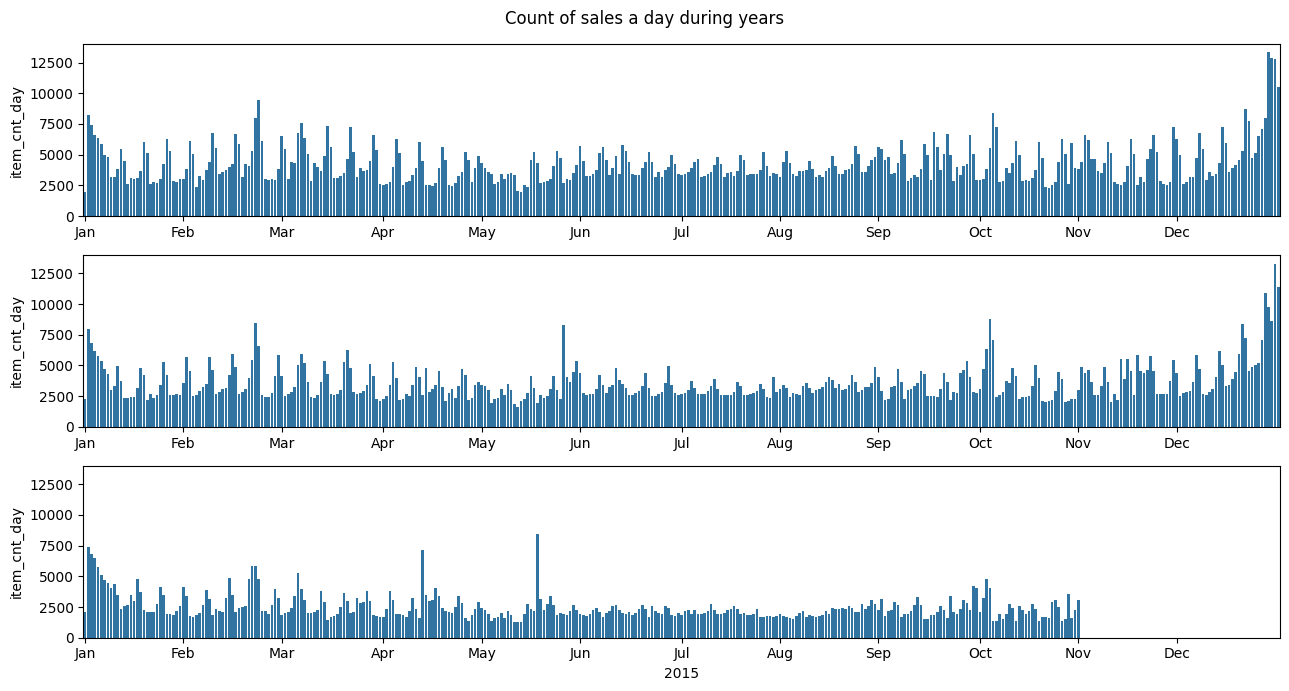

In [25]:
# sales over the days

sales_train_df['day'] = sales_train_df['date'].dt.dayofyear
sales_train_df['year'] = sales_train_df['date'].dt.year
temp = sales_train_df.groupby(['year', 'day']).agg({'item_cnt_day': 'sum'}).reset_index()

fig, axes = plt.subplots(3, 1, sharey=True, figsize=(13, 7), sharex=True)
fig.suptitle('Count of sales a day during years')

# sales for a specific year
sns.barplot(data=temp[temp['year'] == 2013], x='day', y='item_cnt_day', ax=axes[0])
axes[0].set_xlabel('2013')

sns.barplot(data=temp[temp['year'] == 2014], x='day', y='item_cnt_day', ax=axes[1])
axes[1].set_xlabel('2014')

sns.barplot(data=temp[temp['year'] == 2015], x='day', y='item_cnt_day', ax=axes[2])
axes[2].set_xlabel('2015')


for ax in axes:
    ax.set_xticks(np.linspace(0, 364, 12, endpoint=False, dtype=int))
    ax.tick_params(labelbottom=True)
    ax.set_xticklabels(
        ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
         "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"],
    )

plt.tight_layout()
plt.show()

# As we can see, there is season behavior of data, every New Year we can see explosion of count of sales

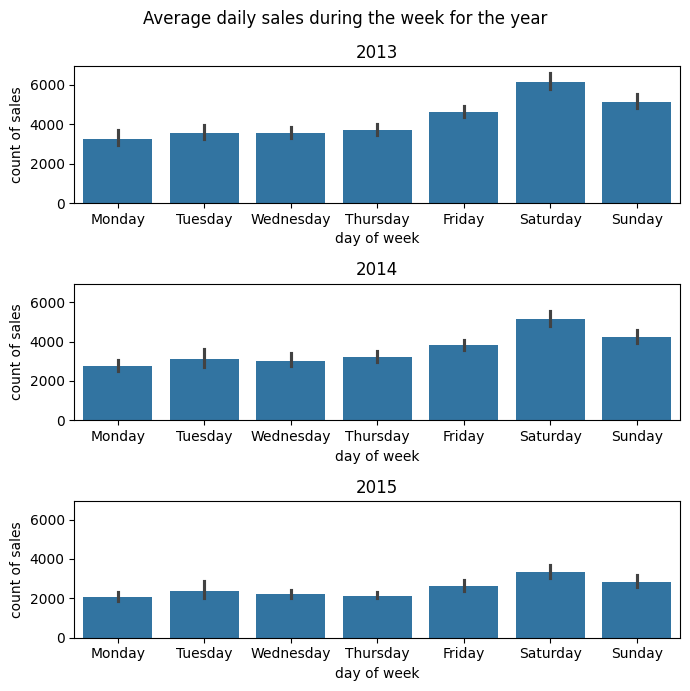

In [26]:
# weekly dynamics of the sales per first year

temp = sales_train_df.copy()
temp['day_name'] = temp['date'].dt.day_name()
temp['month_name'] = temp['date'].dt.month_name()

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
temp['day_name'] = pd.Categorical(temp['day_name'], categories=days_order, ordered=True)

temp = temp.groupby(['year', 'date_block_num', 'day']).agg({'item_cnt_day': 'sum', 'day_name': 'first', 'month_name': 'first'}).reset_index()

fig, axes = plt.subplots(3, 1, figsize=(7, 7), sharey=True)
fig.suptitle('Average daily sales during the week for the year')

for i, ax in enumerate(axes):
    temp_block = temp[temp['year'] == i+2013].reset_index()
    sns.barplot(data=temp_block.sort_values('day_name'), x='day_name', y='item_cnt_day', ax=ax)
    ax.set_xlabel('day of week')
    ax.set_ylabel('count of sales')
    ax.set_title(str(i+2013))

plt.tight_layout()
plt.show()

We can see strong week seasonality

In [27]:
# top 5 maximum values of item_cnt_day

sales_train_df.sort_values(by=['item_cnt_day'], ascending=False) \
    .head() \
    .drop(['date', 'date_block_num', 'item_category_id', 'shop_id'], axis=1)

,item_id,item_price,item_cnt_day,item_category_name,item_name,day,year
2909818,11373,0.908714,2169.0,Доставка товара,Доставка до пункта выдачи (Boxberry),301,2015
2326930,20949,4.000000,1000.0,"Подарки - Сумки, Альбомы, Коврики д/мыши",Фирменный пакет майка 1С Интерес белый (34*42)...,15,2015
2864235,9248,1692.526158,669.0,Служебные - Билеты,"Билет ""ИгроМир 2015"" - 3 октября 2015 (сайт) [...",273,2015
2851091,9249,1702.825746,637.0,Билеты (Цифра),"Билет ""ИгроМир 2015"" - 3 октября 2015 (сайт) У...",273,2015
2608040,3731,1904.548077,624.0,Игры PC - Стандартные издания,"Grand Theft Auto V [PC, русские субтитры]",104,2015


In [28]:
# top 5 minimum values of item_cnt_day

sales_train_df.sort_values(by=['item_cnt_day']) \
    .head() \
    .drop(['date', 'date_block_num', 'item_category_id', 'shop_id'], axis=1)

,item_id,item_price,item_cnt_day,item_category_name,item_name,day,year
1057907,8023,15.000000,-22.0,"Подарки - Открытки, наклейки",ZL004 Лазерные наклейки Смайлики маленькие,306,2013
1835454,20949,5.000000,-16.0,"Подарки - Сумки, Альбомы, Коврики д/мыши",Фирменный пакет майка 1С Интерес белый (34*42)...,191,2014
2048519,9242,1433.333333,-9.0,Билеты (Цифра),"Билет ""ИгроМир 2014"" (на один день (отдельно -...",283,2014
59156,1590,2599.000000,-6.0,Игры PC - Коллекционные издания,"Assassin’s Creed 3. Freedom Edition [PC, русск...",18,2013
940092,3732,2599.000000,-6.0,Игры - PS3,"Grand Theft Auto V [PS3, русские субтитры]",292,2013


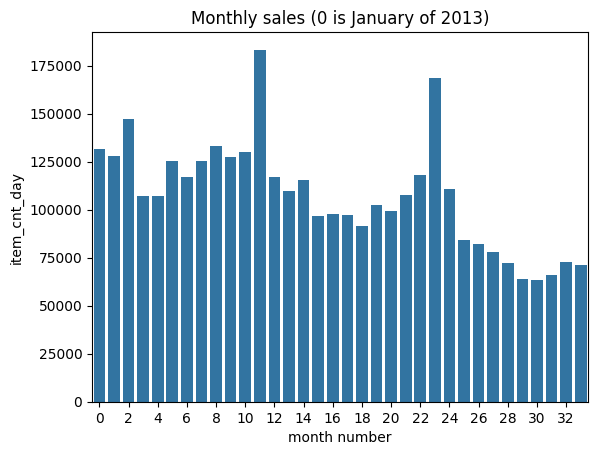

In [29]:
# monthly sales

ax = sns.barplot(sales_train_df.groupby(['date_block_num'])['item_cnt_day'].sum())

ax.set_xticks(np.arange(0, 33, 2, dtype=int))
ax.set_title('Monthly sales (0 is January of 2013)')
ax.set_xlabel('month number')
plt.show()

# As we can see average value of monthly sales is almost always equal to 1

In [30]:
# we can see that 75% of data is less or equal to 1
sales_train_df[['item_cnt_day']].describe().T

,count,mean,std,min,25%,50%,75%,max
item_cnt_day,2935849.0,1.242641,2.618834,-22.0,1.0,1.0,1.0,2169.0


### Equal shop names 

In [31]:
# add shop names into sales_df
sales_train_df.join(shops_df['shop_name'], on='shop_id')

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,item_category_id,item_category_name,item_name,day,year,shop_name
0,2013-01-02,0,59,22154,999.00,1.0,37,Кино - Blu-Ray,ЯВЛЕНИЕ 2012 (BD),2,2013,"Ярославль ТЦ ""Альтаир"""
1,2013-01-03,0,25,2552,899.00,1.0,58,Музыка - Винил,DEEP PURPLE The House Of Blue Light LP,3,2013,"Москва ТРК ""Атриум"""
2,2013-01-05,0,25,2552,899.00,-1.0,58,Музыка - Винил,DEEP PURPLE The House Of Blue Light LP,5,2013,"Москва ТРК ""Атриум"""
3,2013-01-06,0,25,2554,1709.05,1.0,58,Музыка - Винил,DEEP PURPLE Who Do You Think We Are LP,6,2013,"Москва ТРК ""Атриум"""
4,2013-01-15,0,25,2555,1099.00,1.0,56,Музыка - CD фирменного производства,DEEP PURPLE 30 Very Best Of 2CD (Фирм.),15,2013,"Москва ТРК ""Атриум"""
...,...,...,...,...,...,...,...,...,...,...,...,...
2935844,2015-10-10,33,25,7409,299.00,1.0,55,Музыка - CD локального производства,V/A Nu Jazz Selection (digipack),283,2015,"Москва ТРК ""Атриум"""
2935845,2015-10-09,33,25,7460,299.00,1.0,55,Музыка - CD локального производства,V/A The Golden Jazz Collection 1 2CD,282,2015,"Москва ТРК ""Атриум"""
2935846,2015-10-14,33,25,7459,349.00,1.0,55,Музыка - CD локального производства,V/A The Best Of The 3 Tenors,287,2015,"Москва ТРК ""Атриум"""
2935847,2015-10-22,33,25,7440,299.00,1.0,57,Музыка - MP3,V/A Relax Collection Planet MP3 (mp3-CD) (jewel),295,2015,"Москва ТРК ""Атриум"""


In [51]:
from rapidfuzz import fuzz, process

def find_equals_name(strings: list, threshold: int = 80) -> dict:
    results = []
    equal_shop_name: dict = {}
    for i, string in enumerate(strings):
        choices = strings[i + 1 :]

        match = process.extractOne(string, choices, scorer=fuzz.ratio)

        if match and match[1] >= threshold:
            results.append(
                {
                    "original_1": string,
                    "original_2": choices[match[2]],
                    "similarity": match[1],
                    "id_1": i,
                    "id_2": match[2] + i + 1,
                }
            )
    results.sort(key=lambda x: x["similarity"], reverse=True)
    for i, res in enumerate(results):
        print(
            f"({i + 1}/{len(results)})"
            f"Which name is correct (similarity {res["similarity"]: .5})\n"
            f"\t1) {res['original_1']} {res['id_1']}\n"
            f"\t2) {res['original_2']} {res['id_2']}\n"
            f"\t3) Skip\n"
            f"\t4) Skip all"
        )
        choice = int(input())
        match choice:
            case 1:
                equal_shop_name[res["id_2"]] = res["id_1"]
            case 2:
                equal_shop_name[res["id_1"]] = res["id_2"]
            case 3:
                pass
            case 4:
                break
    print(equal_shop_name)
    return equal_shop_name

In [52]:
def find_equal( strings: list, threshold: int = 80) -> None:
    results = []
    equal_shop_name: dict = {}
    for i, string in enumerate(strings):
            choices = strings[i+1:]
            
            match = process.extractOne(string, choices, scorer=fuzz.ratio)
    
            if match and match[1] >= threshold:
                results.append({
                    'original_1': string,
                    'original_2': choices[match[2]],
                    'similarity': match[1],
                    'id_1': i,
                    'id_2': match[2] + i+1
                })
    for i, res in enumerate(results):
        print(f"({i+1}/{len(results)}) Which name is correct (similarity {res['similarity']:.5})\n \
        1) {res['original_1']} {res['id_1']}\n \
        2) {res['original_2']} {res['id_2']}\n \
        3) Skip"
             )
        choice = int(input())
        match choice:
            case 1:
                equal_shop_name[res['id_2']] = res['id_1']
            case 2:
                equal_shop_name[res['id_1']] = res['id_2']
            case 3:
                pass
    print(equal_shop_name)
    results.sort(key=lambda x: x['similarity'], reverse=True)
    print(len(results))
    print("\n".join([f"{res['original_1']}\n{res['original_2']}\n{res['similarity']}\nid_1: {res['id_1']}\nid_2: {res['id_2']}\n" for res in results]))

In [ ]:
# item category similarity check
find_equal(item_categories_df['item_category_name'].to_list())

(1/24) Which name is correct (similarity 93.75)
         1) Аксессуары - PS2 1
         2) Аксессуары - PS3 2
         3) Skip


### Check for unseen data in test subset

In [59]:
# count of unique shops in test subset
len(test_df['shop_id'].unique())

42

In [61]:
# count of unique shops in train subset
len(sales_train_df['shop_id'].unique())

60

In [65]:
# count of shops that test subset includes and train doesn't 
train_unique = set(sales_train_df['shop_id'].unique())
sum([item not in train_unique for item in test_df['shop_id'].unique()])

0

In [66]:
# count of unique items id in train subset
len(sales_train_df['item_id'].unique())

21807

In [71]:
# count of item ids that test subset includes and train doesn't
train_items = set(sales_train_df['item_id'].unique())
absent_items = [item for item in tqdm(test_df['item_id'].unique()) if item not in train_items]
len(absent_items)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5100/5100 [00:00<00:00, 1635018.76it/s]


363

So there are 363 items that our model will see for the first time

In [73]:
# count of item categories that test subset includes and train doesn't
sum([item not in sales_train_df['item_category_id'].unique() for item in tqdm(test_df['item_category_id'].unique())])

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 62/62 [00:00<00:00, 69.14it/s]


0

### Negative price

In [77]:
# find all samples that have negative price
sales_train_df[sales_train_df['item_price'] <= 0]

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,item_category_id,item_category_name,item_name,day,year
484683,2013-05-15,4,32,2973,-1.0,1.0,19,Игры - PS3,"DmC Devil May Cry [PS3, русские субтитры]",135,2013


In [85]:
# as we can see the price of items may change
sales_train_df[sales_train_df['item_id'] == 2973]['item_price'].describe()

count     780.000000
mean     2041.627277
std       584.281629
min        -1.000000
25%      1249.500000
50%      2499.000000
75%      2499.000000
max      2499.000000
Name: item_price, dtype: float64

### Price outliers

Text(0, 0.5, 'mean item price')

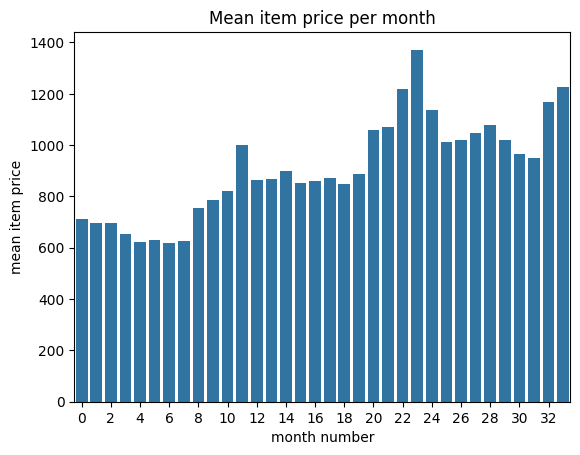

In [99]:
axes = sns.barplot(data=sales_train_df.groupby(['date_block_num'])['item_price'].mean().reset_index(), x='date_block_num', y='item_price')
axes.set_title('Mean item price per month')
axes.set_xticks(np.arange(0, 33, 2))
axes.set_xlabel('month number')
axes.set_ylabel('mean item price')

Text(0, 0.5, 'sum of price')

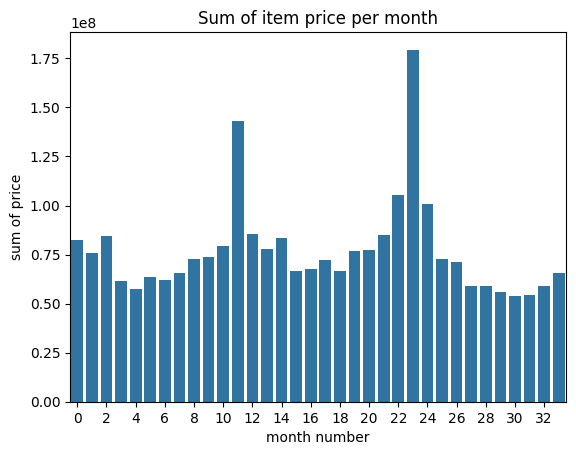

In [102]:
axes = sns.barplot(data=sales_train_df.groupby(['date_block_num'])['item_price'].sum().reset_index(), x='date_block_num', y='item_price')
axes.set_title('Sum of item price per month')
axes.set_xticks(np.arange(0, 33, 2))
axes.set_xlabel('month number')
axes.set_ylabel('sum of price')
# also, we can see season behavior

In [109]:
# calculate metrics for std and iqr methods to handle with outliers

price_mean = sales_train_df['item_price'].mean()
price_std = sales_train_df['item_price'].std()
price_median = sales_train_df['item_price'].median()

q1 = sales_train_df['item_price'].quantile(0.25)
q3 = sales_train_df['item_price'].quantile(0.75)
iqr = q3 - q1


# calculate outliers masks
price_outliers_mask = ~sales_train_df['item_price'].between(price_mean - price_std * 3,
                                                            price_mean + price_std * 3)
price_outliers_iqr_mask = ~sales_train_df['item_price'].between(q1 - 1.5*iqr, q3 + 1.5*iqr)

print(f"std method border: [{price_mean - price_std * 3}, {price_mean + price_std * 3}]")
print(f"iqr method border: [{q1 - 1.5*iqr}, {q3 + 1.5*iqr}]")

std method border: [-4298.545659439973, 6080.252124835997]
iqr method border: [-876.0, 2124.0]


In [110]:
# find total amount of samples to calculate how much data we lose
total_samples = len(sales_train_df)

price_without_outliers = sales_train_df[~price_outliers_mask]
price_without_outliers_iqr = sales_train_df[~price_outliers_iqr_mask]

std method lose: 28701 (0.98%)
iqr method lose: 258942 (8.82%)


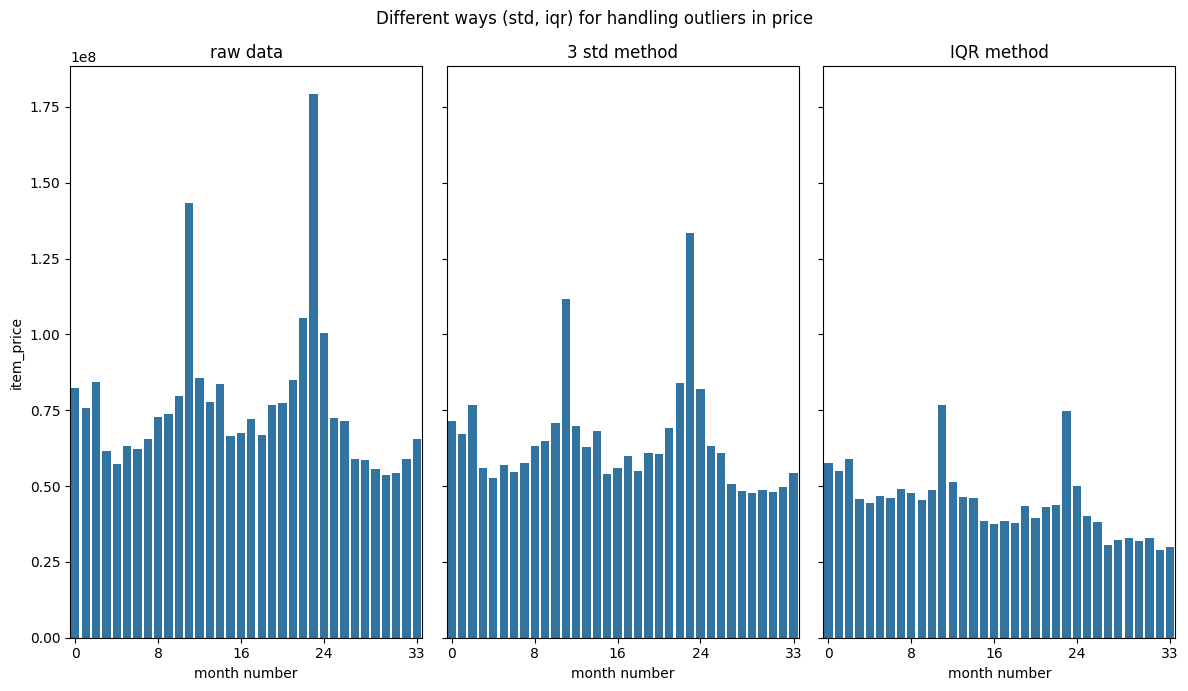

In [148]:
print(f"std method lose: {price_outliers_mask.sum()} ({price_outliers_mask.sum()/total_samples:.2%})") 
print(f"iqr method lose: {price_outliers_iqr_mask.sum()} ({price_outliers_iqr_mask.sum()/total_samples:.2%})")

fig, axes = plt.subplots(1, 3, sharey=True, figsize=(12, 7))

fig.suptitle('Different ways (std, iqr) for handling outliers in price')
sns.barplot(sales_train_df.groupby('date_block_num')['item_price'].sum(), ax=axes[0])
axes[0].set_title('raw data')
sns.barplot(price_without_outliers.groupby('date_block_num')['item_price'].sum(), ax=axes[1])
axes[1].set_title('3 std method')
sns.barplot(price_without_outliers_iqr.groupby('date_block_num')['item_price'].sum(), ax=axes[2])
axes[2].set_title('IQR method')

for ax in axes:
    ax.set_xticks(np.linspace(0, 33, 5, dtype=int))
    ax.set_xlabel('month number')

plt.tight_layout()
plt.show()

### Item per day outliers

In [133]:
# calculate metrics for different methods to handle with outliers
mean = sales_train_df['item_cnt_day'].mean()
std = sales_train_df['item_cnt_day'].std()

q1 = sales_train_df['item_cnt_day'].quantile(0.25)
q3 = sales_train_df['item_cnt_day'].quantile(0.75)
iqr = q3 - q1

MAD = (sales_train_df['item_cnt_day'] - mean).abs().mean() * 1.4826

# outliers masks and subsets without ouliers
item_day_std_mask = ~sales_train_df['item_cnt_day'].between(mean - 3*std, mean + 3*std)
item_day_iqr_mask = ~sales_train_df['item_cnt_day'].between(q1 - 1.5*iqr, q3 + 1.5*iqr)
item_day_MAD_mask = ~sales_train_df['item_cnt_day'].between(mean - 3*MAD, mean + 3*MAD)

item_day_std = sales_train_df[~item_day_std_mask]
item_day_iqr = sales_train_df[~item_day_iqr_mask]
item_day_MAD = sales_train_df[~item_day_MAD_mask]

total_samples = len(sales_train_df)

In [134]:
print('Borders of each method')
print("std: ", mean - 3*std, mean + 3*std)
print("iqr: ", q1 - 1.5*iqr, q3 + 1.5*iqr)
print("MAD: ", mean - 3*MAD, mean + 3*MAD)

Borders of each method
std:  -6.6138624075453825 9.099144177827164
iqr:  1.0 1.0
MAD:  -0.7410194020580976 3.2263011723398796


Count of deleted data
std method: 11939 (0.41%)
iqr method: 306477 (10.44%)
MAD method: 64926 (2.21%)


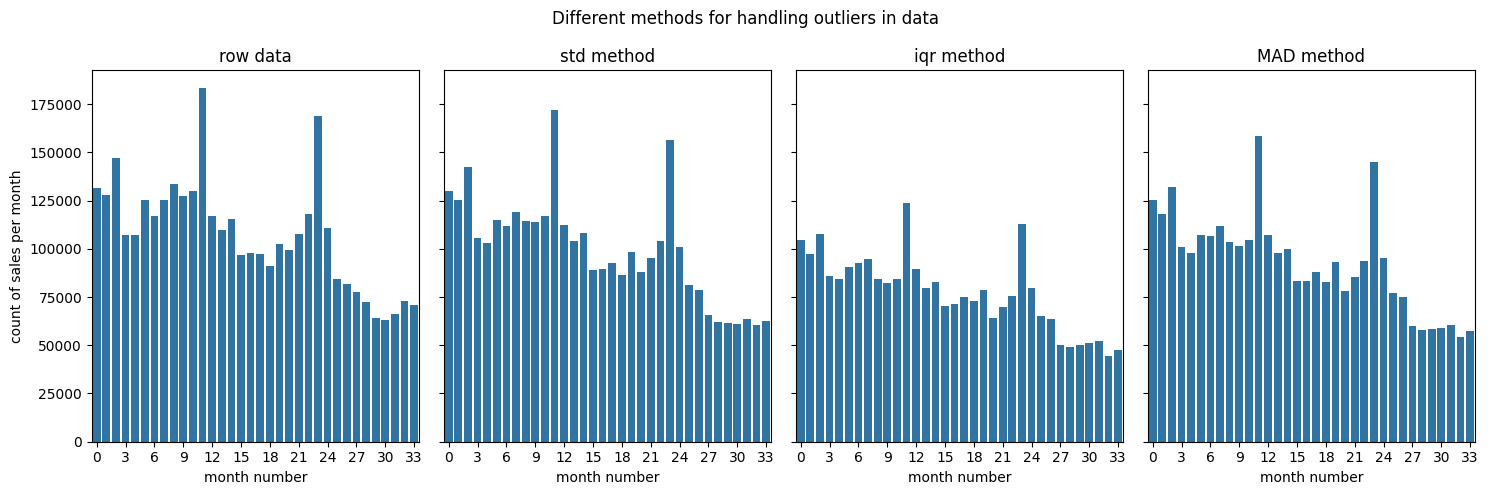

In [150]:
print('Count of deleted data')
print(f"std method: {item_day_std_mask.sum()} ({item_day_std_mask.sum()/total_samples:.2%})") 
print(f"iqr method: {item_day_iqr_mask.sum()} ({item_day_iqr_mask.sum()/total_samples:.2%})")
print(f"MAD method: {item_day_MAD_mask.sum()} ({item_day_MAD_mask.sum()/total_samples:.2%})")

fig, axes = plt.subplots(1, 4, figsize=(15, 5), sharey=True)
fig.suptitle('Different methods for handling outliers in data')

sns.barplot(sales_train_df.groupby(['date_block_num'])['item_cnt_day'].sum(), ax=axes[0])
axes[0].set_title("row data")
sns.barplot(item_day_std.groupby('date_block_num')['item_cnt_day'].sum(), ax=axes[1])
axes[1].set_title('std method')
sns.barplot(item_day_iqr.groupby('date_block_num')['item_cnt_day'].sum(), ax=axes[2])
axes[2].set_title('iqr method')
sns.barplot(item_day_MAD.groupby('date_block_num')['item_cnt_day'].sum(), ax=axes[3])
axes[3].set_title('MAD method')

for ax in axes:
    ax.set_xticks(np.arange(0, 34, 3))
    ax.set_xlabel('month number')
    ax.set_ylabel('count of sales per month')

plt.tight_layout()
plt.show()

### Move to cnt_month

In [153]:
# transform data to good view for model (group data by sales per month)

sales = sales_train_df.groupby(['date_block_num', 'shop_id', 'item_id']).agg({
    'item_cnt_day': 'sum',
    'item_price': 'first',
    'item_category_id': 'first'
}).reset_index()
sales.rename(columns={'item_cnt_day': 'item_cnt_month'}, inplace=True)
sales = sales.drop('item_price', axis=1)

In [154]:
sales.head(3)

,date_block_num,shop_id,item_id,item_cnt_month,item_category_id
0,0,0,32,6.0,40
1,0,0,33,3.0,37
2,0,0,35,1.0,40


min: -22.0 max: 2253.0


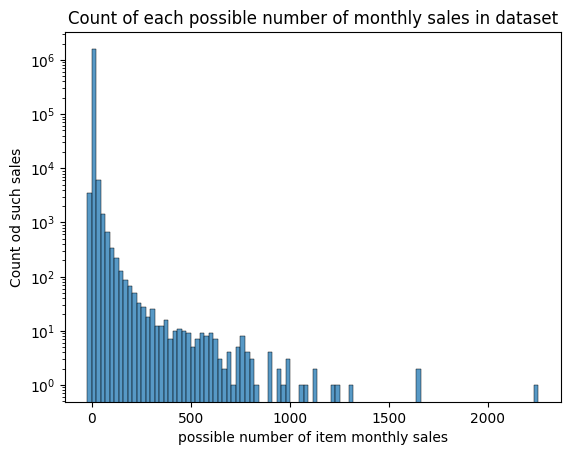

In [231]:
# check variation in the number of identical sales
print(f"min: {sales['item_cnt_month'].min()} max: {sales['item_cnt_month'].max()}")

axis = sns.histplot(sales['item_cnt_month'], bins=100)
axis.set_xlabel('possible number of item monthly sales')
axis.set_ylabel('Count od such sales')

# use log axis to compare huge amount of 1 and others 
plt.yscale('log')
plt.title('Count of each possible number of monthly sales in dataset')
plt.show()

as we can see, huge amount of sales equals to 1 per month

In [233]:
# percent of 1 in data (about 65% of data is 1)
len(sales[sales['item_cnt_month'] == 1])/len(sales) * 100

65.80133041331806

### Monthly sales outliers

In [234]:
mean = sales['item_cnt_month'].mean()
std = sales['item_cnt_month'].std()

q1 = sales['item_cnt_month'].quantile(0.25)
q3 = sales['item_cnt_month'].quantile(0.75)
iqr = q3 - q1

MAD = (sales['item_cnt_month'] - mean).abs().mean() * 1.4826

item_month_std_mask = ~sales['item_cnt_month'].between(mean - 3*std, mean + 3*std)
item_month_iqr_mask = ~sales['item_cnt_month'].between(q1 - 1.5*iqr, q3 + 1.5*iqr)
item_month_MAD_mask = ~sales['item_cnt_month'].between(mean - 3*MAD, mean + 3*MAD)

item_month_std = sales[~item_month_std_mask]
item_month_iqr = sales[~item_month_iqr_mask]
item_month_MAD = sales[~item_month_MAD_mask]

total_samples = len(sales)

In [236]:
print('Borders of differents methods')
print("std: ", mean - 3*std, mean + 3*std)
print("iqr: ", q1 - 1.5*iqr, q3 + 1.5*iqr)
print("MAD: ", mean - 3*MAD, mean + 3*MAD)

Borders of differents methods
std:  -23.682445352388527 28.216845435912234
iqr:  -0.5 3.5
MAD:  -5.59175210113494 10.126152184658647


Amount of deleted data
std method: 6871 (0.43%)
iqr method: 178987 (11.12%)
MAD method: 34000 (2.11%)


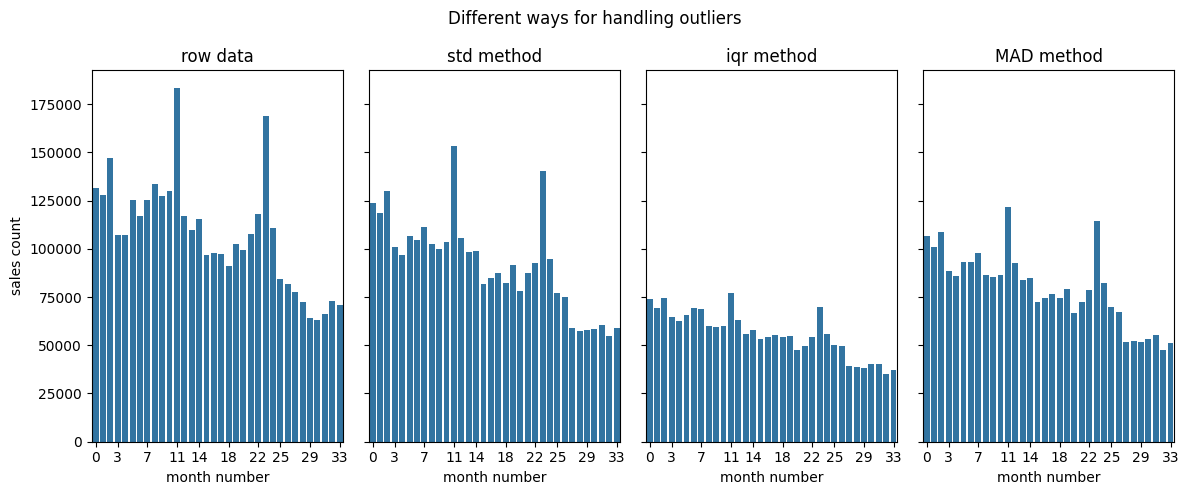

In [240]:
print('Amount of deleted data')
print(f"std method: {item_month_std_mask.sum()} ({item_month_std_mask.sum()/total_samples:.2%})") 
print(f"iqr method: {item_month_iqr_mask.sum()} ({item_month_iqr_mask.sum()/total_samples:.2%})")
print(f"MAD method: {item_month_MAD_mask.sum()} ({item_month_MAD_mask.sum()/total_samples:.2%})")


fig, axes = plt.subplots(1, 4, figsize=(12, 5), sharey=True)
fig.suptitle('Different ways for handling outliers')

sns.barplot(sales.groupby(['date_block_num'])['item_cnt_month'].sum(), ax=axes[0])
axes[0].set_title("row data")
sns.barplot(item_month_std.groupby('date_block_num')['item_cnt_month'].sum(), ax=axes[1])
axes[1].set_title('std method')
sns.barplot(item_month_iqr.groupby('date_block_num')['item_cnt_month'].sum(), ax=axes[2])
axes[2].set_title('iqr method')
sns.barplot(item_month_MAD.groupby('date_block_num')['item_cnt_month'].sum(), ax=axes[3])
axes[3].set_title('MAD method')

for ax in axes:
    ax.set_xlabel('month number')
    ax.set_ylabel('sales count')
    ax.set_xticks(np.linspace(0, 33, 10, dtype=int))

plt.tight_layout()
plt.show()

## Вывод

Есть отрицательная цена, < 0 вроде 1 ----------------------------------------------

Есть выброс по цене товара, > 40_000 14 выбросов (пока цены игнорируем)

Есть выброс по количеству купленных за один день ( > 270 ) 26 выбросов ------------

Есть повторяющиеся названия магазинов ---------------------------------------------

Есть items которые есть в train выборке но нет в test (добавим category_id) -------

Очевидная сезонность (по годам и по неделям)